# Writer / Editor Hidden-State Probe

**Four-arm comparison of agent communication via hidden states**

| Arm | Key | What it does |
|-----|-----|--------------|
| A | `editor_verdict` | Editor receives the **raw essay text** in its prompt |
| B | `editor_selfhs_verdict` | Editor's **own final-layer hidden states** over the draft span are re-injected at `inject_layer` |
| C | `editor_writerhs_verdict` | The **writer's final-layer hidden states** (over its answer tokens) are injected into the editor at `inject_layer` |
| D | `writer_selfhs_output` | Writer's **own final-layer hidden states** (full-sentence answer) are re-injected into the **writer** itself, with a user-configurable prompt (default: "repeat this message"). Sanity check that the HS actually encode the essay content |

Comparing A, B, C, D isolates where communication loss occurs between agents:
- **A ≈ B** → the editor's internal representation carries the same info as the surface text
- **A ≈ C** → the writer's hidden states carry the same info as its decoded text
- **B ≈ C** → writer and editor form compatible internal representations
- **D ≈ answer** → writer's HS genuinely encode the essay content (if this fails, Arm C won't either)

**Communication Gap (CG) metric** — `comm_gap` in the state — is a single scalar distance between the editor's next-token distributions on the **text channel** (Arm A input) vs. the **latent channel** (Arm C input), scored under teacher forcing on Arm A's response. Low CG = channels agree; high CG = the writer's latent and its decoded text carry different information *from the editor's perspective*.

**Total cost per run: 5 `generate()` calls + 2 fast forward passes** — 1 writer + 3 editor (A, B, C) + 1 writer self-probe (D) + 2 teacher-forced forwards for CG.

### Qwen3 / Qwen3.5 — thinking mode
Reasoning stays **ON** by default.  `ModelBackend` automatically strips `<think>…</think>` blocks from
`output_text` and `gen_token_ids` so verdicts are always clean text. Raw thinking is still accessible via `result.thinking_text`.

### Supported models

| Family | Example IDs | Notes |
|--------|------------|-------|
| **Qwen 3.5** | `Qwen/Qwen3.5-0.8B` · `Qwen/Qwen3.5-4B` · `Qwen/Qwen3.5-9B` · `Qwen/Qwen3.5-27B` · `Qwen/Qwen3.5-35B-A3B` (MoE) · `Qwen/Qwen3.5-122B-A10B` (MoE) | Thinking stripped automatically |
| **Qwen 2.5** | `Qwen/Qwen2.5-{0.5,1.5,3,7,14,32,72}B-Instruct` | Standard path |
| **LLaMA 3.x** | `meta-llama/Llama-3.3-70B-Instruct` | Standard path |
| **Gemma 3/4** | `google/gemma-3-{4b,12b,27b}-it` | Standard path |
| **K2-V2** | `LLM360/K2-V2-Instruct` | Use `K2V2Backend` for `reasoning_effort` |

## 0 — Install

In [2]:
# Install the package + all ML dependencies from GitHub:
!pip install -q git+https://github.com/abhipa871/reagent.git@metric

!pip install -q --upgrade "git+https://github.com/huggingface/transformers.git@main"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import time
import torch

from selfie_k2v2 import (
    ModelBackend,
    K2V2Backend,
    HiddenStateProjector,
    make_graph,
    add_probe_to_graph,
    ProbeMixin,
)

## 1 — Choose your model(s)

Writer and editor can be the **same** instance (shared weights) or
**different** `ModelBackend` instances for cross-model experiments.

### 1a — Qwen 3.5 (all sizes)

Reasoning is **ON**. `<think>…</think>` blocks are stripped automatically from verdicts.
Access raw thinking via `final["writer_result"].thinking_text`.

| Model ID | Params | VRAM (bf16) | Notes |
|----------|--------|-------------|-------|
| `Qwen/Qwen3.5-0.8B` | 0.9 B | ~2 GB | dev / smoke-test |
| `Qwen/Qwen3.5-4B` | ~4 B | ~8 GB | single consumer GPU |
| `Qwen/Qwen3.5-9B` | ~9 B | ~18 GB | single A100-40 GB |
| `Qwen/Qwen3.5-27B` | 28 B | ~55 GB | 2× A100-40 GB or 1× H100 |
| `Qwen/Qwen3.5-35B-A3B` | 36 B total / ~3 B active | ~18 GB active | MoE — fast |
| `Qwen/Qwen3.5-122B-A10B` | 122 B / ~10 B active | ~40 GB active | MoE — large |

In [6]:
# ── Qwen 3.5 ───────────────────────────────────────────────────────────────────────────
# Reasoning stays ON. <think>…</think> stripped from verdicts automatically.
# Uncomment one size.

# QWEN35_ID = "Qwen/Qwen3.5-4B"
# QWEN35_ID = "Qwen/Qwen3.5-0.8B"       # smallest — smoke tests
# QWEN35_ID = "Qwen/Qwen3.5-9B"
QWEN35_ID = "Qwen/Qwen3.5-27B"
# QWEN35_ID = "Qwen/Qwen3.5-35B-A3B"    # MoE, ~3B active
# QWEN35_ID = "Qwen/Qwen3.5-122B-A10B"  # MoE, ~10B active

t0 = time.time()
backend = ModelBackend(
    model_name=QWEN35_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    # To hard-disable thinking (faster, less compute):
    chat_template_kwargs={"enable_thinking": False},
)
print(f"Loaded in {time.time()-t0:.1f}s")
print(f"  hidden_size    = {backend.hidden_size}")
print(f"  num_layers     = {backend.num_layers}")
print(f"  strip_thinking = {backend._strip_thinking}")

writer_backend = editor_backend = backend

# ── Fast-path sanity check (Qwen 3.5 only) ────────────────────────────────────────────
# Warn LOUDLY if the linear-attention CUDA kernels aren't installed — without
# them Qwen 3.5 runs 10-20× slower because DeltaNet layers fall back to a pure
# Python `for` loop.
if "qwen3.5" in QWEN35_ID.lower() or "qwen3_5" in QWEN35_ID.lower():
    try:
        import fla  # flash-linear-attention
        _fla_ok = True
    except ImportError:
        _fla_ok = False
    try:
        import causal_conv1d
        _ccc_ok = True
    except ImportError:
        _ccc_ok = False

    if not (_fla_ok and _ccc_ok):
        print("\n" + "!" * 78)
        print("! WARNING: Qwen 3.5 fast path is NOT available.")
        print(f"!   flash-linear-attention : {'OK' if _fla_ok else 'MISSING'}")
        print(f"!   causal-conv1d          : {'OK' if _ccc_ok else 'MISSING'}")
        print("! The model will run 10-20× slower.")
        print("! Re-run the install cell and restart the runtime, or switch to")
        print("! Qwen 2.5 / LLaMA / Gemma which don't need these kernels.")
        print("!" * 78)
    else:
        print("\nQwen 3.5 fast path: flash-linear-attention + causal-conv1d detected.")

Loading Qwen/Qwen3.5-27B ...
  → Qwen3/3.5 detected: reasoning ON, <think> blocks stripped from output.


tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/851 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Ready. hidden_size=5120, num_layers=64, device=cuda:0
Loaded in 167.4s
  hidden_size    = 5120
  num_layers     = 64
  strip_thinking = True

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
! WARNING: Qwen 3.5 fast path is NOT available.
!   flash-linear-attention : MISSING
!   causal-conv1d          : MISSING
! The model will run 10-20× slower.
! Re-run the install cell and restart the runtime, or switch to
! Qwen 2.5 / LLaMA / Gemma which don't need these kernels.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
# ── Qwen 3.5 with 4-bit quantization (fits on a 16 GB GPU) ───────────────
# from transformers import BitsAndBytesConfig
# bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
#                          bnb_4bit_quant_type="nf4")
# backend = ModelBackend("Qwen/Qwen3.5-27B", dtype=torch.bfloat16,
#                        device_map="auto", quantization_config=bnb)
# writer_backend = editor_backend = backend

### 1b — Other supported models

In [ ]:
# ── Other families (uncomment one) ───────────────────────────────────────────────────

# Qwen 2.5
# backend = ModelBackend("Qwen/Qwen2.5-7B-Instruct", dtype=torch.bfloat16, device_map="auto")

# LLaMA 3.3
# backend = ModelBackend("meta-llama/Llama-3.3-70B-Instruct", dtype=torch.bfloat16, device_map="auto")

# Gemma 3
# backend = ModelBackend("google/gemma-3-27b-it", dtype=torch.bfloat16, device_map="auto")

# K2-V2
# backend = K2V2Backend(dtype=torch.bfloat16, device_map="auto")

# writer_backend = editor_backend = backend

### 1c — Cross-model (different writer / editor)

In [ ]:
# writer_backend = ModelBackend("Qwen/Qwen3.5-9B",  dtype=torch.bfloat16, device_map="auto")
# editor_backend = ModelBackend("Qwen/Qwen3.5-27B", dtype=torch.bfloat16, device_map="auto")
# proj = HiddenStateProjector.between(writer_backend, editor_backend)
# print(f"Projection: {proj.src_size} → {proj.tgt_size}  needs={proj.needs_projection}")

## 2 — Sanity check

In [7]:
t0 = time.time()
ids = writer_backend.build_chat_prompt(
    system="You are a helpful assistant.",
    user="Say hi in 5 words.",
)
r = writer_backend.generate(ids, max_new_tokens=256, capture_hidden=True)
print(f"[{time.time()-t0:.1f}s]")
print(f"output_text   : {r.output_text!r}")
if r.thinking_text:
    print(f"thinking      : {r.thinking_text[:120]}...")

# Verify HS covers ALL answer tokens (needed for full injection into editor)
hs_len    = r.hidden_states[-1].shape[1]
full_len  = r.output_ids.shape[1]
ans_start = r.prompt_len + r.answer_offset
ans_end   = ans_start + len(r.gen_token_ids)
print(f"prompt_len    = {r.prompt_len}")
print(f"answer_offset = {r.answer_offset}  (thinking tokens skipped)")
print(f"answer tokens = {len(r.gen_token_ids)}  positions [{ans_start}, {ans_end})")
print(f"HS length     = {hs_len}  full_len = {full_len}")

assert r.output_text.strip(), "Empty output — check model load or chat template."
assert "<think>" not in r.output_text, "Thinking stripping failed."
assert hs_len == full_len, (
    f"HS length ({hs_len}) < output length ({full_len}). "
    "generate() must capture HS for all tokens (capture_all_tokens=True, default)."
)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[3.2s]
output_text   : 'Hello there, how are you?'
prompt_len    = 30
answer_offset = 0  (thinking tokens skipped)
answer tokens = 8  positions [30, 38)
HS length     = 38  full_len = 38


## 3 — Build the graph and run all four arms

```
writer → probe_editor            (A: raw text → editor, also captures editor HS)
       → probe_editor_selfhs     (B: editor's own HS re-injected at inject_layer)
       → probe_editor_writerhs   (C: writer's answer HS injected into editor at inject_layer)
       → probe_writer_selfhs     (D: writer's answer HS re-injected into writer, user-configurable prompt)
       → probe_comm_gap          (CG metric: Arm A vs. Arm C logits, teacher-forced)
       → END
```

**Injection is always all at once:** for each arm, every answer/draft token is replaced in a **single**
vectorised forward pass — not one token at a time. `inject_layer` picks **one** layer (0 = embedding
output, `num_layers//2` = mid-stack, etc.); HS are overwritten at that layer only and the rest of the
forward pass runs normally.

**Arm D (writer self-probe):** the writer's full-sentence answer HS are spliced into a short prompt that
asks the writer to describe/repeat the encoded content. The `WRITER_SELFPROBE_USER` string must contain
exactly one `<<<INJECT_HERE>>>` marker — that's where the HS are injected.

**Editable prompts (all in the next cell):**

| Variable | Controls |
|----------|----------|
| `WRITER_SYSTEM` | Writer agent's system prompt |
| `EDITOR_SYSTEM` | Editor agent's system prompt (used in Arms A, B, C) |
| `WRITER_SELFPROBE_SYSTEM` | Arm D system prompt |
| `WRITER_SELFPROBE_USER` | Arm D user prompt — must contain one `<<<INJECT_HERE>>>` marker |

**Cost = 5 `generate()` calls + 2 fast teacher-forced forward passes per run** (set `RUN_COMM_GAP = False` below to drop the 2 extra forward passes).

In [8]:
TASK = "Describe a golden retriever in 3 sentences."
MAX_WRITER_TOKENS           = 80    # raise to 300+ if thinking is ON and the answer is truncating
MAX_EDITOR_TOKENS           = 48
MAX_WRITER_SELFPROBE_TOKENS = 80    # Arm D generation budget
INJECT_LAYER                = 0     # 0 = embedding; try writer_backend.num_layers // 2 for mid-stack
VERBOSE_TIMING              = True  # print wall time per node

# ── Communication Gap (CG) metric ────────────────────────────────────────────
# CG = mean_t [ CG_BETA * JS_t + CG_ALPHA * COS_t ]
# where JS_t  = Jensen-Shannon divergence between editor softmax(logits) under
#               text channel (Arm A input) and latent channel (Arm C input),
#       COS_t = 1 - cosine(logits_lat[t], logits_text[t]).
# Both channels are evaluated by TEACHER FORCING on Arm A's reference response,
# so divergence reflects channel difference — not autoregressive drift.
RUN_COMM_GAP = True
CG_ALPHA     = 0.5      # weight on cosine term
CG_BETA      = 0.5      # weight on Jensen-Shannon term

# ═════════════════════════════════════════════════════════════════════════════
# ALL PROMPTS ARE EDITABLE HERE. Edit the strings directly.
# ═════════════════════════════════════════════════════════════════════════════

# ── Writer system prompt (used for the writer agent's generation) ────────────
WRITER_SYSTEM = (
    "You are a helpful writing assistant. "
    "Write a clear, concise paragraph (3–4 sentences) on the topic provided."
)

# ── Editor system prompt (used for Arms A, B, and C) ─────────────────────────
EDITOR_SYSTEM = (
    "You are a critical editor. "
    "Evaluate the draft between <DRAFT> and </DRAFT>. "
    "Give one short sentence of feedback: is it clear? Is anything missing?"
)

# ── Arm D prompts: writer self-probe ─────────────────────────────────────────
# The writer's own final-layer hidden states (over its full answer) are
# re-injected into the writer with the prompt below.
#
# WRITER_SELFPROBE_USER MUST contain exactly one "<<<INJECT_HERE>>>" marker —
# that position is where the hidden states get spliced into the residual stream.
#
# Examples to try (swap for WRITER_SELFPROBE_USER below):
#   "The message says: '<<<INJECT_HERE>>>'. In one sentence, what topic does it cover?"
#   "Here is an encoded thought: '<<<INJECT_HERE>>>'. Translate it into plain English:"
#   "A fellow writer handed you this draft (encoded): '<<<INJECT_HERE>>>'.\nWrite a paraphrase of it:"
WRITER_SELFPROBE_SYSTEM = "You are a helpful assistant."
WRITER_SELFPROBE_USER = (
    "The following is a message: '<<<INJECT_HERE>>>'.\n"
    "Repeated word-for-word, the message says:"
)

# ═════════════════════════════════════════════════════════════════════════════

graph = make_graph(
    writer_backend,
    editor_backend,
    max_writer_tokens=MAX_WRITER_TOKENS,
    max_editor_tokens=MAX_EDITOR_TOKENS,
    max_writer_selfprobe_tokens=MAX_WRITER_SELFPROBE_TOKENS,
    inject_layer=INJECT_LAYER,
    writer_system=WRITER_SYSTEM,
    editor_system=EDITOR_SYSTEM,
    writer_selfprobe_system=WRITER_SELFPROBE_SYSTEM,
    writer_selfprobe_user=WRITER_SELFPROBE_USER,
    run_comm_gap=RUN_COMM_GAP,
    cg_alpha=CG_ALPHA,
    cg_beta=CG_BETA,
    verbose_timing=VERBOSE_TIMING,
)

print(f"Task: {TASK!r}")
t0 = time.time()
final = graph.invoke({"task": TASK})
print(f"Done in {time.time()-t0:.1f}s")

Task: 'Describe a golden retriever in 3 sentences.'
  [writer                  ]  10.72s
  [probe_editor            ]   4.62s
  [probe_editor_selfhs     ]   3.90s
  [probe_editor_writerhs   ]   3.73s
  [probe_writer_selfhs     ]   9.76s
  [probe_comm_gap          ]   1.29s
Done in 34.0s


## 4 — Four-arm comparison

In [9]:
print("══ WRITER OUTPUT (clean — thinking stripped) " + "═"*28)
print(final["writer_output_text"])

wr = final["writer_result"]
if wr.thinking_text:
    print(f"\n  [thinking: {len(wr.thinking_text)} chars, {wr.answer_offset} thinking tokens]")

print("\n── Arm A  (raw text → editor) " + "─"*42)
print(final["editor_verdict"])

print("\n── Arm B  (editor's own HS re-injected) " + "─"*31)
print(final["editor_selfhs_verdict"])

print("\n── Arm C  (writer's HS injected into editor) " + "─"*27)
print(final["editor_writerhs_verdict"])

print("\n── Arm D  (writer's HS re-injected into writer — self-probe) " + "─"*11)
print(final["writer_selfhs_output"])

print()
print("A ≈ B       →  editor's internal repr ≡ surface text")
print("A ≈ C       →  writer's hidden states ≡ writer's text")
print("B ≈ C       →  writer and editor share compatible representations")
print("D ≈ answer  →  writer's HS genuinely encode the essay content")

══ WRITER OUTPUT (clean — thinking stripped) ════════════════════════════
Golden retrievers are medium-to-large dogs known for their friendly, tolerant, and intelligent nature. They possess a dense, water-repellent coat that ranges in color from light to deep gold, often featuring a distinctive feathering on their tail and legs. As highly trainable companions, they excel in roles ranging from family pets to service and search-and-rescue dogs.

── Arm A  (raw text → editor) ──────────────────────────────────────────
The draft is clear and well-written, but it would be more complete if it briefly mentioned their high energy levels or exercise requirements.

── Arm B  (editor's own HS re-injected) ───────────────────────────────
The draft is unclear because it reads as a fragmented list of breed traits rather than a complete sentence with a subject and verb.

── Arm C  (writer's HS injected into editor) ───────────────────────────
The draft is a grammatically correct sentence, but it is m

## 5 — Communication Gap metric (text vs. latent channel)

The **Communication Gap (CG)** is a single scalar measuring how differently the editor behaves when reading Arm A's raw text vs. Arm C's injected writer hidden states, **scored on the same reference response** (Arm A's verdict) under teacher forcing.

- **Low CG (≈ 0)** — editor's next-token distributions agree → the writer's latent and its decoded text carry equivalent information *from the editor's perspective*.
- **High CG** — the two channels disagree → measurable communication loss between writer and editor.

`CG = mean_t [ beta · JS_t + alpha · COS_t ]`
- `JS_t` — Jensen-Shannon divergence of softmax logits (in *nats*; bounded in [0, log 2] ≈ 0.693).
- `COS_t` — `1 − cosine(logits_lat[t], logits_text[t])` (scale-invariant logit alignment).

The per-step breakdown lets you see *where* in the response the two channels diverge most.

══ Communication Gap (text channel vs. latent channel) ══════════════════
  response length T : 27 tokens
  alpha (cosine)    : 0.5
  beta  (JS)        : 0.5

  CG                : 0.1435
  mean JS           : 0.1772   (0 = identical, max ≈ 0.693)
  mean (1 - cos)    : 0.1098   (0 = identical direction)


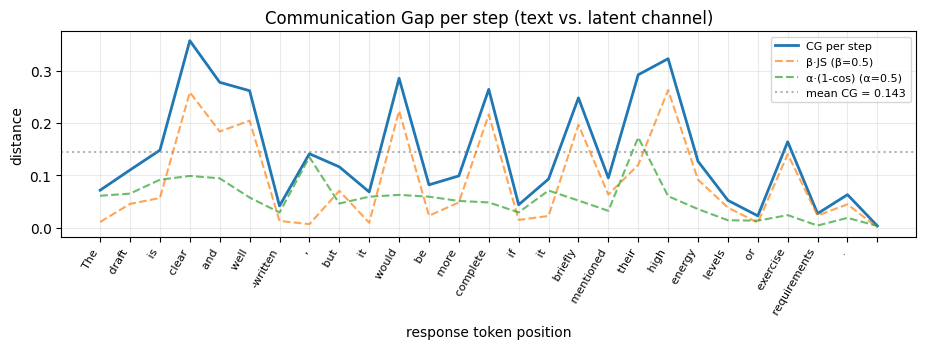

In [10]:
cg = final.get("comm_gap")

if cg is None:
    print("Communication Gap metric not computed (RUN_COMM_GAP=False).")
elif cg.get("T", 0) == 0:
    print(f"Communication Gap skipped: {cg.get('note', 'empty response')}")
else:
    print("══ Communication Gap (text channel vs. latent channel) " + "═"*18)
    print(f"  response length T : {cg['T']} tokens")
    print(f"  alpha (cosine)    : {cg['alpha']}")
    print(f"  beta  (JS)        : {cg['beta']}")
    print()
    print(f"  CG                : {cg['CG']:.4f}")
    print(f"  mean JS           : {cg['JS_mean']:.4f}   (0 = identical, max ≈ 0.693)")
    print(f"  mean (1 - cos)    : {cg['COS_mean']:.4f}   (0 = identical direction)")

    # Per-step plot — where along the response do the channels diverge?
    try:
        import matplotlib.pyplot as plt

        per_step = cg["per_step"].numpy()
        js_ps    = cg["JS_per_step"].numpy()
        cos_ps   = cg["COS_per_step"].numpy()

        # Decode response tokens for x-tick labels
        ref_ids = final["editor_result"].output_ids[0, final["editor_prompt_ids"].shape[1]:].tolist()
        ref_ids = ref_ids[:cg["T"]]
        tok_labels = [
            editor_backend.tokenizer.decode([t], skip_special_tokens=True).replace("\n", "\\n")
            for t in ref_ids
        ]

        fig, ax = plt.subplots(figsize=(max(6, 0.35 * cg["T"]), 3.6))
        xs = range(cg["T"])
        ax.plot(xs, per_step, label="CG per step",       linewidth=2)
        ax.plot(xs, CG_BETA  * js_ps,  label=f"β·JS (β={CG_BETA})",  linestyle="--", alpha=0.7)
        ax.plot(xs, CG_ALPHA * cos_ps, label=f"α·(1-cos) (α={CG_ALPHA})", linestyle="--", alpha=0.7)
        ax.axhline(cg["CG"], color="gray", linestyle=":", alpha=0.6, label=f"mean CG = {cg['CG']:.3f}")
        ax.set_xlabel("response token position")
        ax.set_ylabel("distance")
        ax.set_title("Communication Gap per step (text vs. latent channel)")
        ax.set_xticks(list(xs))
        ax.set_xticklabels(tok_labels, rotation=60, ha="right", fontsize=8)
        ax.legend(loc="best", fontsize=8)
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("\n(install matplotlib to see the per-step CG plot)")

## 6 — (Optional) Inspect writer's thinking

The raw chain-of-thought is preserved in `result.thinking_text` even though it is
stripped from verdicts and from the token sequence used for injection.

In [ ]:
wr = final["writer_result"]
if wr.thinking_text:
    print(f"Writer thinking ({wr.answer_offset} tokens):")
    print(wr.thinking_text)
else:
    print("No thinking block (non-Qwen3 model or thinking was empty)")

## 7 — Plug the probe nodes into an existing LangGraph workflow

If you already have a writer node in your graph, you can bolt the 4 probe
arms onto the end of it. Your state schema just needs to extend `ProbeMixin`.

In [11]:
from langgraph.graph import StateGraph, END

class MyState(ProbeMixin, total=False):
    task: str

def my_writer(state: MyState) -> MyState:
    prompt_ids = writer_backend.build_chat_prompt(
        system="You are a helpful writing assistant.",
        user=state["task"],
    )
    result = writer_backend.generate(prompt_ids, max_new_tokens=80, capture_hidden=True)
    return {
        **state,
        "writer_result": result,
        "writer_output_text": result.output_text,         # clean, thinking stripped
        "writer_output_token_ids": result.gen_token_ids,  # answer tokens only
    }

g = StateGraph(MyState)
g.add_node("my_writer", my_writer)
g.set_entry_point("my_writer")
add_probe_to_graph(
    g,
    writer_backend,
    editor_backend,
    entry_node="my_writer",
    inject_layer=0,
)
app = g.compile()

out = app.invoke({"task": "Explain why the sky is blue in two sentences."})
print("Arm A:", out["editor_verdict"])
print("Arm B:", out["editor_selfhs_verdict"])
print("Arm C:", out["editor_writerhs_verdict"])
print("Arm D:", out["writer_selfhs_output"])
if "comm_gap" in out and out["comm_gap"].get("T", 0) > 0:
    cg2 = out["comm_gap"]
    print(f"CG   : {cg2['CG']:.4f}   (JS={cg2['JS_mean']:.4f}, 1-cos={cg2['COS_mean']:.4f})")

Arm A: The draft is clear and accurately explains the phenomenon, though it could be slightly more precise by noting that the sun emits more blue light than violet light rather than just "more blue light."
Arm B: The draft is confusing because it incorrectly attributes the scattering of blue light to the sun's emission spectrum rather than atmospheric physics.
Arm C: The draft is confusing because it incorrectly states that the sky appears blue due to the scattering of red and yellow light, when in fact it is the scattering of shorter blue wavelengths that causes this effect.
Arm D: 'the sky appears blue because shorter wavelengths of light, such as blue and violet, are scattered more effectively by the atmosphere than longer wavelengths like red and yellow, which pass through more directly; however, our eyes are more sensitive to blue light, and the sun emits more blue light than violet, so we perceive the sky as blue.'
CG   : 0.1477   (JS=0.1820, 1-cos=0.1135)


## 8 — Save outputs (optional)

In [ ]:
import os

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

wr = final["writer_result"]
with open(f"{out_dir}/arm_verdicts.txt", "w", encoding="utf-8") as f:
    f.write(f"model        : {writer_backend.model_name}\n")
    f.write(f"task         : {TASK}\n")
    f.write(f"inject_layer : {INJECT_LAYER}\n")
    f.write(f"thinking_len : {wr.answer_offset} tokens\n\n")
    if wr.thinking_text:
        f.write(f"=== Writer thinking ===\n{wr.thinking_text}\n\n")
    f.write(f"=== Writer output (clean) ===\n{final['writer_output_text']}\n\n")
    f.write(f"=== Arm A: editor_verdict (raw text) ===\n{final['editor_verdict']}\n\n")
    f.write(f"=== Arm B: editor_selfhs_verdict (editor's own HS) ===\n{final['editor_selfhs_verdict']}\n\n")
    f.write(f"=== Arm C: editor_writerhs_verdict (writer's HS) ===\n{final['editor_writerhs_verdict']}\n\n")
    f.write(f"=== Arm D: writer_selfhs_output (writer's HS → writer) ===\n{final['writer_selfhs_output']}\n\n")
    cg = final.get("comm_gap")
    if cg and cg.get("T", 0) > 0:
        f.write(f"=== Communication Gap ===\n")
        f.write(f"T         : {cg['T']}\n")
        f.write(f"alpha     : {cg['alpha']}\n")
        f.write(f"beta      : {cg['beta']}\n")
        f.write(f"CG        : {cg['CG']:.6f}\n")
        f.write(f"JS_mean   : {cg['JS_mean']:.6f}\n")
        f.write(f"COS_mean  : {cg['COS_mean']:.6f}\n")

print(f"Saved to ./{out_dir}/arm_verdicts.txt")